In [93]:

import numpy as np
import pandas as pd
import os
import zipfile
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [94]:

!wget "https://github.com/awsaf49/flickr-dataset/releases/download/v1.0/flickr8k.zip"
!unzip -q flickr8k.zip -d ./flickr8k

--2026-05-03 10:09:44--  https://github.com/awsaf49/flickr-dataset/releases/download/v1.0/flickr8k.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/753516996/d7c62b13-1e50-40ea-8fae-f34a44b1695f?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-03T10%3A57%3A08Z&rscd=attachment%3B+filename%3Dflickr8k.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-05-03T09%3A56%3A45Z&ske=2026-05-03T10%3A57%3A08Z&sks=b&skv=2018-11-09&sig=7II61cvJGaQp69DrTzHVRZfR2UAb4VAUPI74hwvWspo%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NzgwNjU4NCwibmJmIjoxNzc3ODAyOTg0LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmN

In [95]:

print(os.listdir("/content/Flicker8k_Dataset"))

['3332136681_9aecf101fd.jpg', '384465575_31294122c0.jpg', '3256456935_664a7a5bba.jpg', '3585495069_33cba06d0a.jpg', '2705947033_5999147842.jpg', '2272489996_95b0a62d15.jpg', '241347150_5ff37818c2.jpg', '3549464203_8ab9c6160b.jpg', '3095137758_bdd1e613dd.jpg', '2790909995_8b7a03d9d1.jpg', '3348785391_c243faf6bb.jpg', '2306674172_dc07c7f847.jpg', '1794818900_e0ffdd268e.jpg', '2473293833_78820d2eaa.jpg', '1423997242_ea2189ec5e.jpg', '485357535_b45ba5b6da.jpg', '3534668485_6887629ff0.jpg', '2981702521_2459f2c1c4.jpg', '3296584432_bef3c965a3.jpg', '2616673985_fa4354cc53.jpg', '2390778197_4d9d03d4b9.jpg', '887108308_2da97f15ef.jpg', '3582689770_e57ab56671.jpg', '3728256505_7f8db8270d.jpg', '2139519215_8ca16dd192.jpg', '3074617663_2f2634081d.jpg', '3429641260_2f035c1813.jpg', '2990977776_1ec51c9281.jpg', '2611651553_61f859837e.jpg', '3422979565_e08cd77bfe.jpg', '2613920405_e91e6ebd7a.jpg', '3613800013_5a54968ab0.jpg', '2508918369_2659db1cb6.jpg', '3030223792_02b6f2be99.jpg', '2865703567_52de2

In [96]:

print(len(os.listdir("/content/Flicker8k_Dataset")))

8091


In [97]:
files = os.listdir("/content/Flicker8k_Dataset")
print(files[:20])

['3332136681_9aecf101fd.jpg', '384465575_31294122c0.jpg', '3256456935_664a7a5bba.jpg', '3585495069_33cba06d0a.jpg', '2705947033_5999147842.jpg', '2272489996_95b0a62d15.jpg', '241347150_5ff37818c2.jpg', '3549464203_8ab9c6160b.jpg', '3095137758_bdd1e613dd.jpg', '2790909995_8b7a03d9d1.jpg', '3348785391_c243faf6bb.jpg', '2306674172_dc07c7f847.jpg', '1794818900_e0ffdd268e.jpg', '2473293833_78820d2eaa.jpg', '1423997242_ea2189ec5e.jpg', '485357535_b45ba5b6da.jpg', '3534668485_6887629ff0.jpg', '2981702521_2459f2c1c4.jpg', '3296584432_bef3c965a3.jpg', '2616673985_fa4354cc53.jpg']


In [98]:
with open("Flickr8k.token.txt","r") as f:
    lines = f.readlines()
print(len(lines))

40460


In [99]:
model = InceptionV3(weights='imagenet')
model = tf.keras.Model(
    model.input,
    model.layers[-2].output
)

model_encoder = model
print("Encoder Loaded")

Encoder Loaded


In [100]:
def extract_features(directory):

    features={}

    for img in os.listdir(directory)[:100]:
        path=directory+"/"+img

        image=load_img(path,target_size=(299,299))
        image=img_to_array(image)

        image=np.expand_dims(image,axis=0)
        image=preprocess_input(image)

        feature=model.predict(image,verbose=0)

        features[img]=feature

    return features

features = extract_features("Flicker8k_Dataset")
print("Feature extraction completed")

Feature extraction completed


In [101]:
def load_captions(filename):

    mapping={}

    with open(filename,'r') as file:

        for line in file:
            # Flickr8k.token.txt is tab-separated
            tokens=line.strip().split('\t')

            # The first part contains img_id#caption_num, extract img_id
            img_id_with_num = tokens[0]
            img_id = img_id_with_num.split('#')[0]
            caption = tokens[1]

            if img_id not in mapping:
                mapping[img_id]=[]

            mapping[img_id].append(
                "startseq " + caption + " endseq"
            )

    return mapping

captions=load_captions(
    "Flickr8k.token.txt"
)

print("Captions Loaded")

Captions Loaded


In [102]:
from tensorflow.keras.preprocessing.text import Tokenizer

all_captions=[]

for key in captions:
    for cap in captions[key]:
        all_captions.append(cap)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)

vocab_size = len(tokenizer.word_index)+1

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 8496


In [103]:

max_length = max(
    len(c.split())
    for c in all_captions
)

print("Max Caption Length:", max_length)

Max Caption Length: 40


In [104]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Training data lists
X1 = []
X2 = []
y = []

count = 0

for img, caption_list in captions.items():

    # Skip if image feature not extracted
    if img not in features:
        continue

    for caption in caption_list:

        # Convert caption words to numbers
        seq = tokenizer.texts_to_sequences(
            [caption]
        )[0]

        # Create input-output pairs
        for i in range(1, len(seq)):

            # Input sequence
            in_seq = seq[:i]

            # Next word (target)
            out_seq = seq[i]

            # Pad sequence
            in_seq = pad_sequences(
                [in_seq],
                maxlen=max_length
            )[0]

            # Store training data
            X1.append(features[img][0])
            X2.append(in_seq)

            # Store target as integer
            y.append(out_seq)

    count += 1

    # Use 50 images first to reduce RAM
    if count == 500:
        break


# Convert lists to arrays
X1 = np.array(X1)
X2 = np.array(X2)
y  = np.array(y)

print("Training data ready")
print(X1.shape)
print(X2.shape)
print(y.shape)

Training data ready
(6001, 2048)
(6001, 40)
(6001,)


In [105]:
from tensorflow.keras.layers import Input,Dense,LSTM,Embedding,Dropout,add
from tensorflow.keras.models import Model

inputs1 = Input(shape=(2048,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(256,activation='relu')(fe1)

inputs2 = Input(shape=(max_length,))

# FIXED
se1 = Embedding(vocab_size,256)(inputs2)

se2 = Dropout(0.5)(se1)
se3 = LSTM(256)(se2)

decoder1 = add([fe2,se3])
decoder2 = Dense(256,activation='relu')(decoder1)

outputs = Dense(
    vocab_size,
    activation='softmax'
)(decoder2)

model = Model(
    inputs=[inputs1,inputs2],
    outputs=outputs
)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam'
)

print(model.summary())

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_18      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 40, 256)   │  2,174,976 │ input_layer_19[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 2048)      │          0 │ input_layer_18[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 40, 256)   │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 256)       │    524,544 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 256)       │    525,312 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 256)       │          0 │ dense_12[0][0],   │
│                     │                   │            │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 256)       │     65,792 │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 8496)      │  2,183,472 │ dense_13[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,474,096 (20.88 MB)

 Trainable params: 5,474,096 (20.88 MB)

 Non-trainable params: 0 (0.00 B)

None


In [106]:
model.fit(
    [X1, X2],
    y,
    epochs=25,
    batch_size=32
)

Epoch 1/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5.7167
Epoch 2/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.6009
Epoch 3/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.9944
Epoch 4/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.4413
Epoch 5/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.9449
Epoch 6/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.5387
Epoch 7/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.1930
Epoch 8/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.9565
Epoch 9/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.7304
Epoch 10/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.5629
Epoch 11/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.3864
Epoch 12/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.2570
Epoch 13/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.1247
Epoch 14/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.0143
Epoch 15/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/st

In [107]:

def generate_caption(model, image_feature):

    caption = "startseq"

    for i in range(max_length):

        seq = tokenizer.texts_to_sequences(
            [caption]
        )[0]

        seq = pad_sequences(
            [seq],
            maxlen=max_length
        )

        yhat = model.predict(
            [image_feature, seq],
            verbose=0
        )

        yhat = np.argmax(yhat)

        word = None

        for w, index in tokenizer.word_index.items():
            if index == yhat:
                word = w
                break

        if word is None:
            break

        caption += " " + word

        if word == "endseq":
            break


    # Remove startseq and endseq
    return caption.replace(
        "startseq",""
    ).replace(
        "endseq",""
    ).strip()

In [108]:
test_img = list(features.keys())[57]

print(test_img)

print(
generate_caption(
    model,
    features[test_img]
)
)

3696246123_99d4d10140.jpg
two dogs play with a ball in a field


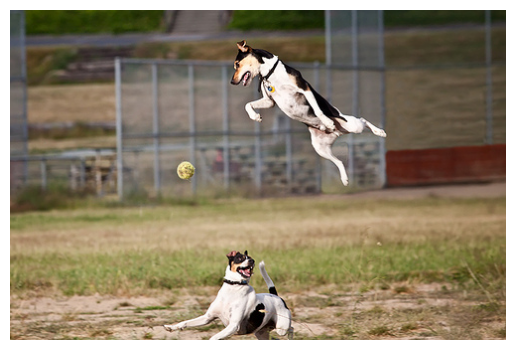

In [109]:
import matplotlib.pyplot as plt
from PIL import Image

test_img = list(features.keys())[57]

img = Image.open(
    "Flicker8k_Dataset/" + test_img
)

plt.imshow(img)
plt.axis("off")

caption = generate_caption(
    model,
    features[test_img]
)


In [129]:
from google.colab import files
files.upload()

Saving 23445819_3a458716c1.jpg to 23445819_3a458716c1 (1).jpg


{'23445819_3a458716c1 (1).jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00d\x00d\x00\x00\xff\xdb\x00C\x00\x06\x04\x05\x06\x05\x04\x06\x06\x05\x06\x07\x07\x06\x08\n\x10\n\n\t\t\n\x14\x0e\x0f\x0c\x10\x17\x14\x18\x18\x17\x14\x16\x16\x1a\x1d%\x1f\x1a\x1b#\x1c\x16\x16 , #&\')*)\x19\x1f-0-(0%()(\xff\xdb\x00C\x01\x07\x07\x07\n\x08\n\x13\n\n\x13(\x1a\x16\x1a((((((((((((((((((((((((((((((((((((((((((((((((((\xff\xc0\x00\x11\x08\x01=\x01\x90\x03\x01\x11\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1c\x00\x00\x02\x03\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x04\x05\x02\x03\x06\x01\x07\x00\x08\xff\xc4\x00B\x10\x00\x02\x01\x02\x04\x04\x03\x06\x05\x02\x05\x04\x02\x02\x02\x03\x01\x02\x03\x04\x11\x00\x05\x12!\x131AQ"aq\x06\x142\x81\x91\xa1#B\xb1\xc1\xf0R\xd1\x07\x15b\xe1\xf1$3r\x82C\x92%\xb2\x08\xa2c\xc2\xd2\xff\xc4\x00\x1a\x01\x00\x03\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x00\x04\x05\x06\xff\xc4\x001\x11\x01\x00\x02\x01\x04\x01\x03\x01\x08\x02\x03\x01\x01\

In [124]:

def extract_feature_single(img_path):

    image = load_img(img_path, target_size=(299,299))
    image = img_to_array(image)

    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)

    feature = model_encoder.predict(image, verbose=0)

    return feature


Generated Caption: a man on a dirt bike zipping away while another another races by


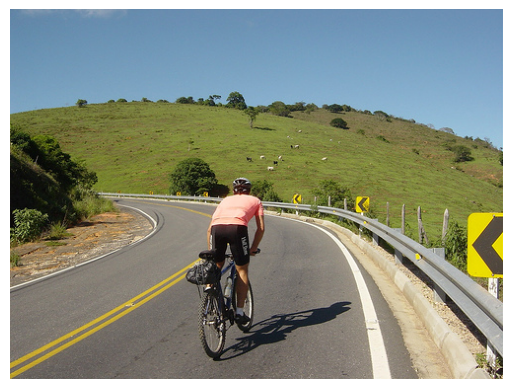

In [131]:
import matplotlib.pyplot as plt
from PIL import Image

img_path = "110595925_f3395c8bd6.jpg"
img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")

feature = extract_feature_single(img_path)
caption = generate_caption(model, feature)

print("Generated Caption:", caption)